# Dimensionality Reduction

**PCA Feature Extraction of FRED and Index Variables**

Author: Pete King

We reduce the dimensionality of the FRED and index variables using Principal Component Analysis (PCA) for a few reasons:
 1. To reduce "noise" in the data and emphasize the singal we want our models to pay attention to
 2. To reduce multicollinearity in the data
 3. To extract a smaller set of features to use as input variables to our models

Rather than lump all variables together in a single run, we separate variables into major groups, based on the correlation analysis we did as part of our data exploration:

 - Volatility indicies: VIX, VXN, MOVE
 - Historical volatility for non-volatility indicies: Commodities, equity indicies, and ETFs
 - Recent returns for non-volatility indicies
 - Macroeconomic data and other infrequently reported variables


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import data_prep as dp
import viz

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TEST_DATA_FILE = DATA_FOLDER + 'test_ALL_DATA.csv'

## I. Data Preparation

### Import financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
test_df = pd.read_csv(
    TEST_DATA_FILE,
    index_col='date',
    parse_dates=True
)

### Separate features into desired groups

In [3]:
X_cols, _ = dp.get_X_y_cols(train_df, returns=True)
# Volatility indicies
vol = ['^MOVE', '^VIX', '^VXN']
# Macroeconomic and other variables
macro = [
    'one_month_yield_diff', 'three_month_yield_diff', 'six_month_yield_diff',
    'one_year_yield_diff', 'two_year_yield_diff', 'five_year_yield_diff',
    'ten_year_yield_diff', 'thirty_year_yield_diff',
    '^TNX_diff',
    'nominal_GDP_chg', 'real_GDP_chg', 'debt_to_GDP_chg', 'debt_interest_chg',
    'consumer_price_index_chg', 'core_PCI_chg',
    'personal_consumption_expenditure_chg', 'core_PCE_chg',
    'producer_price_index_chg', 'unemployment_rate_chg',
    'teenager_unemployment_rate_chg', 'adult_unemployment_rate_chg',
    'male_unemployment_rate_chg', 'female_unemployment_rate_chg',
    'average_duration_of_unemployment_chg',
    'initial_jobless_claims_chg',
    'continued_jobless_claims_chg'
]
# Historical volatility and recent return for non-volatility indicies
p_vol = re.compile(r'.+_vol-h$')
p_ret = re.compile(r'.+_ret-h$')
hvol = [var for var in X_cols if p_vol.match(var) is not None]
hret = [var for var in X_cols if p_ret.match(var) is not None]

### Scale data

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = pd.DataFrame(
    scaler.fit_transform(train_df[X_cols]),
    index=train_df.index,
    columns=X_cols
)
X_val = pd.DataFrame(
    scaler.transform(val_df[X_cols]),
    index=val_df.index,
    columns=X_cols
)
X_test = pd.DataFrame(
    scaler.transform(test_df[X_cols]),
    index=test_df.index,
    columns=X_cols
)

## II. Apply PCA for feature extraction

*Note: We only fit PCA to training data to avoid data leakage*

In [5]:
# Volatility indicies
pca_vol = PCA()
X_train_vol = pca_vol.fit_transform(X_train[vol])
X_val_vol = pca_vol.transform(X_val[vol])
X_test_vol = pca_vol.transform(X_test[vol])
# Macroeconomic data
pca_macro = PCA()
X_train_macro = pca_macro.fit_transform(X_train[macro])
X_val_macro = pca_macro.transform(X_val[macro])
X_test_macro = pca_macro.transform(X_test[macro])
# Historical volatility of non-volatility indicies
pca_hvol = PCA()
X_train_hvol = pca_hvol.fit_transform(X_train[hvol])
X_val_hvol = pca_hvol.transform(X_val[hvol])
X_test_hvol = pca_hvol.transform(X_test[hvol])
# Recent returns for non-volatility indicies
pca_hret = PCA()
X_train_hret = pca_hret.fit_transform(X_train[hret])
X_val_hret = pca_hret.transform(X_val[hret])
X_test_hret = pca_hret.transform(X_test[hret])

### Scree plots: Explained variance ratio

#### Volatility Indicies

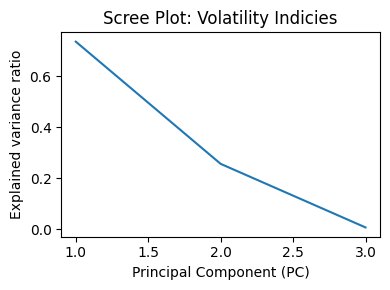

In [6]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_vol.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Volatility Indicies',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [7]:
pca_vol.explained_variance_ratio_

array([0.73618296, 0.25663306, 0.00718397])

The first principal component alone explains 74% of the variation in the volatility indexes.  Taking the first two components would capture 99.3% of the variation.  Since the volatility indexes were consistently ranked among the top features (from examination of regression coefficients and decision tree feature importances), we decide to keep the top two components to include nearly all of the variation in these features.  It's also worth stressing that these indicies are based on advanced economic models designed to predict overall market volatility -- the very reason they are so valuable as features.

#### Macroeconomic Data

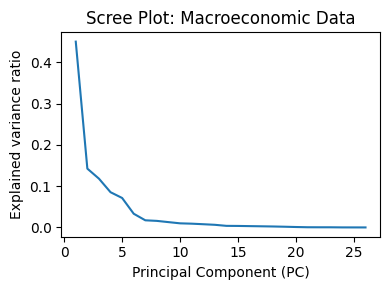

In [8]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_macro.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Macroeconomic Data',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [9]:
pca_macro.explained_variance_ratio_

array([4.50138666e-01, 1.42457572e-01, 1.18159552e-01, 8.53432155e-02,
       7.13914525e-02, 3.31991508e-02, 1.72837064e-02, 1.58808860e-02,
       1.28876370e-02, 9.95437159e-03, 9.12873276e-03, 7.79778397e-03,
       6.38767050e-03, 3.84314275e-03, 3.63949959e-03, 3.20480035e-03,
       2.78141478e-03, 2.33303736e-03, 1.73564639e-03, 1.03347794e-03,
       4.76932876e-04, 3.85719196e-04, 3.69380446e-04, 1.03064158e-04,
       5.78475798e-05, 2.56403433e-05])

The first four principal components explain 80% of the variation in macroeconomic data.

#### Historical Volatility (of non-volatility indicies)

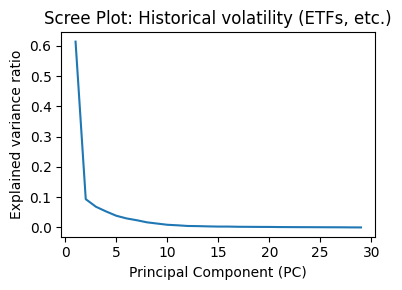

In [10]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_hvol.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Historical volatility (ETFs, etc.)',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [11]:
pca_hvol.explained_variance_ratio_

array([6.14083080e-01, 9.35122958e-02, 6.84095983e-02, 5.28273955e-02,
       3.86201565e-02, 2.98558007e-02, 2.39171090e-02, 1.69554778e-02,
       1.28922104e-02, 8.87010249e-03, 7.10776399e-03, 4.90324763e-03,
       4.40002715e-03, 3.53351278e-03, 2.90176153e-03, 2.86992863e-03,
       2.22975070e-03, 2.05314369e-03, 1.78837910e-03, 1.69839225e-03,
       1.33078117e-03, 1.15038296e-03, 9.89634413e-04, 8.93779495e-04,
       7.64558732e-04, 6.00415082e-04, 5.25294443e-04, 2.37979442e-04,
       7.80405340e-05])

The first three principal components explain 78% of the variance in historical volatility for all non-volatility indicies.

#### Recent Returns (of non-volatility indicies)

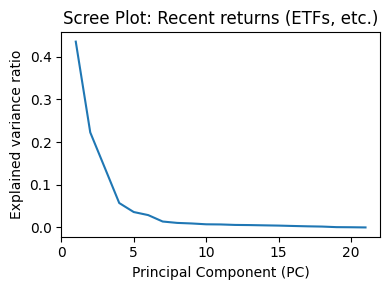

In [12]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_hret.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Recent returns (ETFs, etc.)',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [13]:
pca_hret.explained_variance_ratio_

array([4.35218114e-01, 2.22646722e-01, 1.40110876e-01, 5.72881400e-02,
       3.61937749e-02, 2.90045443e-02, 1.39539108e-02, 1.07260869e-02,
       9.40486568e-03, 7.46352035e-03, 7.11263816e-03, 5.98109623e-03,
       5.62882309e-03, 4.99997193e-03, 4.41618881e-03, 3.52385601e-03,
       2.72217134e-03, 2.14227932e-03, 7.98964958e-04, 5.44957826e-04,
       1.18497900e-04])

The first three principal components explain 80% of the variance in recent returns for all non-volatility indicies.

## III. Save Principal Features

In selecting which principal features to retain, want to strike a balance between capturing variation in the data and increasing the complexity of our models.  As our investigations with the full feature set have shown, not all the variation in these features is relevant to to our target variables.  We choose to retain roughly 80 percent of the variance for each group of features:

 - First 2 principal components for the volatility indicies
 - First 4 principal components for the macroeconomic variables
 - First 3 principal components for historical volatility of ETFs, etc.
 - First 3 principal components for recent returns of ETFs, etc.

### Principal Features: Training Data

In [14]:
# Create PCA column labels
vol_cols = [
    'PCA_vol-1', 'PCA_vol-2'
]
macro_cols = [
    'PCA_macro-1', 'PCA_macro-2', 'PCA_macro-3', 'PCA_macro-4'
]
hvol_cols = [
    'PCA_hvol-1', 'PCA_hvol-2', 'PCA_hvol-3'
]
hret_cols = [
    'PCA_hret-1', 'PCA_hret-2', 'PCA_hret-3'
]
pca_cols = vol_cols + macro_cols + hvol_cols + hret_cols
# Create PCA DataFrame for extracted training features
train_data = np.asarray(
    [
        *[X_train_vol[:, i] for i in range(len(vol_cols))],
        *[X_train_macro[:, i] for i in range(len(macro_cols))],
        *[X_train_hvol[:, i] for i in range(len(hvol_cols))],
        *[X_train_hret[:, i] for i in range(len(hret_cols))]
    ]
)
train_data = train_data.reshape(-1, len(train_data))

In [15]:
pca_train_df = pd.DataFrame(
    train_data,
    columns=pca_cols,
    index=train_df.index
)
pca_train_df

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,
2015-10-22,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192,-0.027020,-0.035612,-0.031673,0.003920,-0.004416,-0.028761
2015-10-23,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960,-0.000326,-0.024071,-0.030029,-0.043408,-0.038998,-0.035716
2015-10-26,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070,-0.043886,-0.037661,-0.007188,0.011014,0.006914,0.076367
2015-10-27,0.080811,0.070985,-0.022329,-0.023923,-0.006781,-0.033949,-0.052711,-0.068107,-0.069678,-0.046203,-0.056724,-0.043523
2015-10-28,-0.030986,0.005244,0.009962,0.023684,0.088783,0.087957,0.062373,0.050440,0.093646,0.074613,0.138485,0.129804
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.308083,0.293317,0.318319,0.347146,0.318630,0.352572,0.230029,0.244636,0.167978,0.168873,0.253616,0.223574
2022-11-28,0.216470,0.328980,0.303408,0.250322,0.259765,0.119006,0.294609,0.296493,0.182851,0.184875,0.276096,0.106277
2022-11-29,0.116745,0.214495,0.206188,0.362023,0.225342,0.231037,0.320214,0.402303,0.318870,0.307361,0.372419,0.285724


### Principal Features: Validation Data

In [16]:
# Create PCA DataFrame for extracted validation features
val_data = np.asarray(
    [
        *[X_val_vol[:, i] for i in range(len(vol_cols))],
        *[X_val_macro[:, i] for i in range(len(macro_cols))],
        *[X_val_hvol[:, i] for i in range(len(hvol_cols))],
        *[X_val_hret[:, i] for i in range(len(hret_cols))]
    ]
)
val_data = val_data.reshape(-1, len(val_data))

In [17]:
pca_val_df = pd.DataFrame(
    val_data,
    columns=pca_cols,
    index=val_df.index
)
pca_val_df

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,
2023-01-03,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311,0.337204,0.291585,0.291259,0.358576,0.305696,0.317675
2023-01-04,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406,0.250842,0.217873,0.185065,0.198466,0.206405,0.258067
2023-01-05,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478,0.260471,0.297770,0.289716,0.382678,0.367219,0.349151
2023-01-06,0.388915,0.363785,0.384096,0.367638,0.377479,0.353326,0.390000,0.430783,0.401736,0.431695,0.521250,0.756041
2023-01-09,0.699941,0.724333,0.684553,0.786744,0.791241,0.633941,0.517984,0.574988,0.709907,0.622068,0.578386,0.536060
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.509651,0.481606,0.525170,0.567170,0.541915,0.505196,0.598294,0.651030,0.650908,0.698193,0.788185,0.639709
2024-08-27,0.554635,0.607626,0.603924,0.728833,0.711125,0.669326,0.697178,0.710301,0.669767,0.606121,0.689005,0.623749
2024-08-28,0.716737,0.673490,0.504542,0.574394,0.530578,0.569836,0.579799,0.571859,0.594947,0.587029,0.616483,0.510084


### Principal Features: Test Data

In [18]:
# Create PCA DataFrame for extracted validation features
test_data = np.asarray(
    [
        *[X_test_vol[:, i] for i in range(len(vol_cols))],
        *[X_test_macro[:, i] for i in range(len(macro_cols))],
        *[X_test_hvol[:, i] for i in range(len(hvol_cols))],
        *[X_test_hret[:, i] for i in range(len(hret_cols))]
    ]
)
test_data = test_data.reshape(-1, len(test_data))

In [19]:
pca_test_df = pd.DataFrame(
    test_data,
    columns=pca_cols,
    index=test_df.index
)
pca_test_df

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,
2024-10-01,0.222081,0.205526,0.214056,0.195804,0.385820,0.372165,0.359116,0.322814,0.330873,0.355470,0.396070,0.350367
2024-10-02,0.344975,0.339205,0.379862,0.381409,0.390816,0.377105,0.394196,0.405892,0.406700,0.408935,0.462560,0.432324
2024-10-03,0.457452,0.403707,0.277027,0.180592,0.149017,0.180296,0.205606,0.156389,0.141941,0.183974,0.177726,0.203188
2024-10-04,0.222746,0.186364,0.150139,0.146215,0.133804,0.123756,0.100696,0.116886,0.100196,0.078861,0.074342,0.013472
2024-10-07,0.045023,0.073855,0.016900,0.023244,0.043607,0.093014,0.102193,0.191800,0.186356,0.136095,0.139604,0.121634
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-19,0.487220,0.370030,0.502608,0.481845,0.525643,0.565418,0.520355,0.599503,0.513195,0.519367,0.551480,0.492862
2026-02-20,0.396918,0.377515,0.384468,0.431774,0.390065,0.307512,0.419146,0.485733,0.344934,0.387267,0.411323,0.550336
2026-02-23,0.479279,0.392858,0.460174,0.480997,0.441981,0.366848,0.383269,0.364002,0.330696,0.338511,0.327426,0.313411


### Save Principal Features as CSV files

In [20]:
pca_train_df.to_csv(
    DATA_FOLDER + 'train_pca_data.csv',
    index_label='date'
)
pca_val_df.to_csv(
    DATA_FOLDER + 'val_pca_data.csv',
    index_label='date'
)
pca_test_df.to_csv(
    DATA_FOLDER + 'test_pca_data.csv',
    index_label='date'
)